In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [2]:
torch.__version__

'2.10.0'

In [3]:
weight = 0.7
bias = 0.3

start = 0
end =1
step = 0.02
x = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * x + bias
x.shape, y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [4]:
x[:10]

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])

In [5]:
y[:10]

tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])

In [6]:
# splitting data into training and test set

In [7]:
train_split = int(0.8 * len(x))
x_train , y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]

In [8]:
len(x_train),len(x_test)

(40, 10)

In [9]:
def plot_pridiction(train_data = x_train, train_labels = y_train, test_data = x_test, test_labels = y_test, predictions= None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data, train_labels, c= "b", s= 15, label= "trainiing data")
    plt.scatter(test_data, test_labels, c="g", s=15, label="predictions")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=15, label="Predictions")
    
    plt.legend(prop={"size": 14})

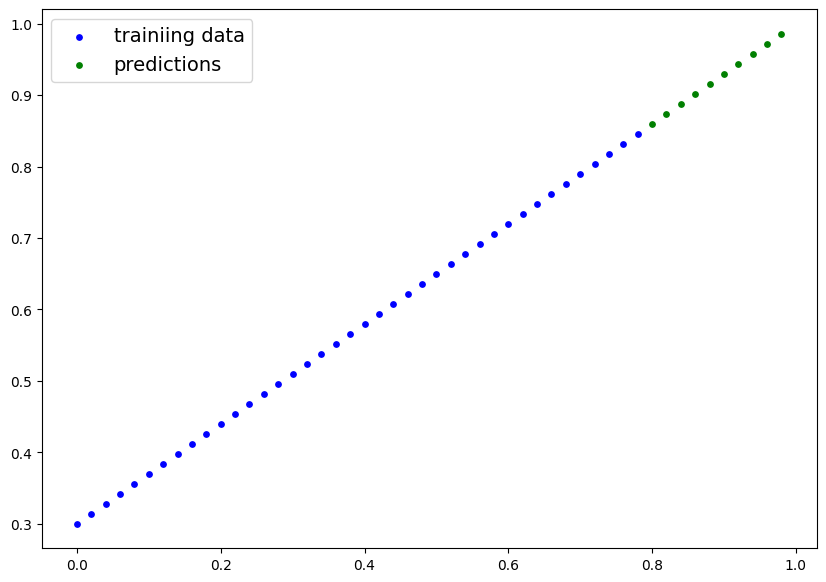

In [10]:
plot_pridiction()

# First pytorch Model 

In [11]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x +self.bias

In [12]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
params = list(model_0.parameters())
for p in params:
    print(p)

Parameter containing:
tensor([0.3367], requires_grad=True)
Parameter containing:
tensor([0.1288], requires_grad=True)


In [13]:
 #making predictions
with torch.inference_mode(): # turns off gradient tracking
    y_preds = model_0(x_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

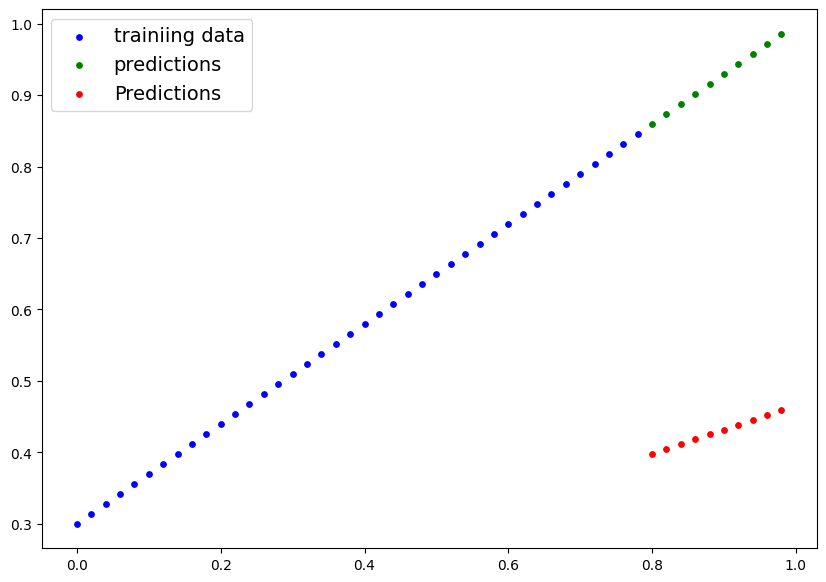

In [14]:
plot_pridiction(predictions= y_preds)

In [15]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

## Training

In [16]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)

In [17]:
epochs =100

ep = []
trainlosses = []
testlosses = []

for epoch in range(1):
    model_0.train()

    # fd pass
    y_pred = model_0(x_train)

    # loss
    loss = loss_fn(y_pred, y_train)


    #optimizer
    optimizer.zero_grad()

    # backprop on the loss wrt to params
    loss.backward()

    # step the optimizer
    optimizer.step()


    model_0.eval() # turns off the grads
    with torch.inference_mode():
        if epoch % 1 == 0:
            test_loss = model_0(x_test)
            # print (f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
            ep.append(epoch)
            trainlosses.append(loss)
            testlosses.append(test_loss[-1])




    

In [18]:
ep[0], trainlosses[0], testlosses[-1][-1]

(0, tensor(0.3129, grad_fn=<MeanBackward0>), tensor(0.5970))

In [19]:
with torch.inference_mode():
    pred0 = model_0(x_test)
    

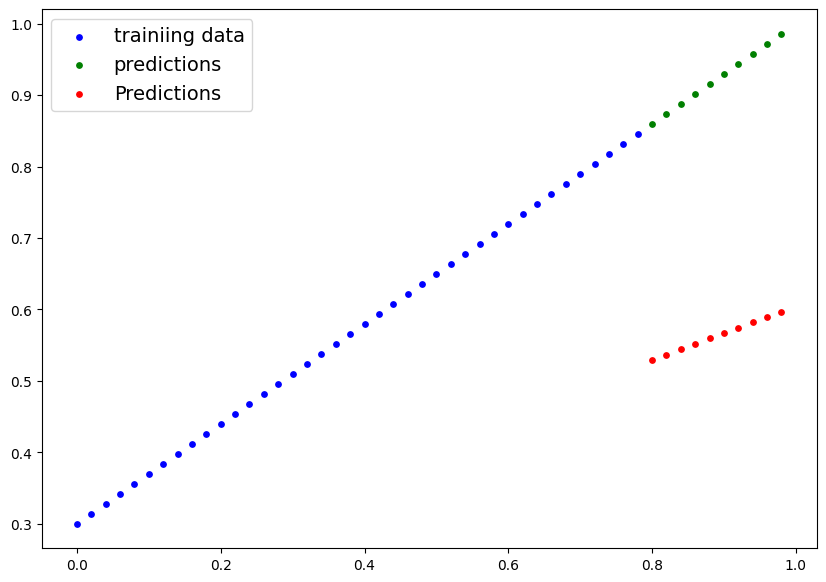

In [20]:
plot_pridiction(predictions=pred0)

In [21]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3757])), ('bias', tensor([0.2288]))])

In [22]:
# ep, testlosses, trainlosses
ep[0], testlosses[-1][-1], trainlosses[-1]


(0, tensor(0.5970), tensor(0.3129, grad_fn=<MeanBackward0>))

In [23]:
from pathlib import Path

In [24]:
model_path = Path("models")
model_path.mkdir(parents=True, exist_ok = True)

# model save path
model_name = "01__pytorch_workflow_model.pth"
model_save_path = model_path/model_name

#model stat dict:
print(f"saving model to: {model_save_path}")
torch.save(obj=model_0.state_dict(), f=model_save_path)

y_preds = model_0(x_test)


saving model to: models/01__pytorch_workflow_model.pth


In [25]:
!ls -l models

total 8
-rw-r--r--@ 1 apple  staff  2109 Mar 27 18:26 01__pytorch_workflow_model.pth


In [26]:
loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(f=model_save_path))

<All keys matched successfully>

In [27]:
loaded_model.eval()

with torch.inference_mode():
    loaded_model_preds = loaded_model(x_test)

loaded_model_preds

tensor([[0.5294],
        [0.5369],
        [0.5444],
        [0.5519],
        [0.5594],
        [0.5669],
        [0.5744],
        [0.5820],
        [0.5895],
        [0.5970]])

In [28]:
#comparing
y_preds, loaded_model_preds

(tensor([[0.5294],
         [0.5369],
         [0.5444],
         [0.5519],
         [0.5594],
         [0.5669],
         [0.5744],
         [0.5820],
         [0.5895],
         [0.5970]], grad_fn=<AddBackward0>),
 tensor([[0.5294],
         [0.5369],
         [0.5444],
         [0.5519],
         [0.5594],
         [0.5669],
         [0.5744],
         [0.5820],
         [0.5895],
         [0.5970]]))